### 671. Second Minimum Node In a Binary Tree

<p>Given a non-empty special binary tree consisting of nodes with the non-negative value, where each node in this tree has exactly <code>two</code> or <code>zero</code> sub-node. If the node has two sub-nodes, then this node&#39;s value is the smaller value among its two sub-nodes. More formally, the property&nbsp;<code>root.val = min(root.left.val, root.right.val)</code>&nbsp;always holds.</p>

<p>Given such a binary tree, you need to output the <b>second minimum</b> value in the set made of all the nodes&#39; value in the whole tree.</p>

<p>If no such second minimum value exists, output -1 instead.</p>

<p>&nbsp;</p>

<p>&nbsp;</p>
<p><strong class="example">Example 1:</strong></p>
<img alt="" src="https://assets.leetcode.com/uploads/2020/10/15/smbt1.jpg" style="width: 431px; height: 302px;" />
<pre>
<strong>Input:</strong> root = [2,2,5,null,null,5,7]
<strong>Output:</strong> 5
<strong>Explanation:</strong> The smallest value is 2, the second smallest value is 5.
</pre>

<p><strong class="example">Example 2:</strong></p>
<img alt="" src="https://assets.leetcode.com/uploads/2020/10/15/smbt2.jpg" style="width: 321px; height: 182px;" />
<pre>
<strong>Input:</strong> root = [2,2,2]
<strong>Output:</strong> -1
<strong>Explanation:</strong> The smallest value is 2, but there isn&#39;t any second smallest value.
</pre>

<p>&nbsp;</p>
<p><strong>Constraints:</strong></p>

<ul>
	<li>The number of nodes in the tree is in the range <code>[1, 25]</code>.</li>
	<li><code>1 &lt;= Node.val &lt;= 2<sup>31</sup> - 1</code></li>
	<li><code>root.val == min(root.left.val, root.right.val)</code>&nbsp;for each internal node of the tree.</li>
</ul>


#### Difficulty: Easy, AC rate: 46.4%

#### Topics:
Tree | Depth-First Search | Binary Tree

#### Links:
 🎁 [Question Detail](https://leetcode.com/problems/second-minimum-node-in-a-binary-tree/description/) | 🎉 [Question Solution](https://leetcode.com/problems/second-minimum-node-in-a-binary-tree/solution/) | 💬 [Question Discussion](https://leetcode.com/problems/second-minimum-node-in-a-binary-tree/discuss/?orderBy=most_votes)



#### Test Case(s):

1. `[2,2,5,null,null,5,7]`
2. `[2,2,2]`

---
What's your idea?

DFS.

For this tree property: $ root = min (left, right) $

- first try smaller node, to get second minimum value result as $ R_{smaller} $
- if $ R_{smaller} \gt 0 $ and $ \lt \text{bigger sibling's value} $, then no nodes in bigger sibling can be smaller than $ R_{smaller} $
- or, if smaller node's value $ \ne $ bigger node's value, bigger node's value is the smallest in this subtree, so is the second minimum of the entire tree
- at last, if the two siblings share the same value, it needs to check the bigger node's second minimum value

---

In [1]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

In [43]:
class Solution:
    def findSecondMinimumValue(self, root: TreeNode | None) -> int:
        if not root or (not root.left and not root.right):
            return -1
            
        smaller_node, bigger_node = root.left, root.right
        if root.right.val < root.left.val:
            smaller_node, bigger_node = root.right, root.left
        smaller_result = self.findSecondMinimumValue(smaller_node)
        if smaller_result > 0 and smaller_result < bigger_node.val:
            return smaller_result
            
        if smaller_node.val != bigger_node.val:
            return bigger_node.val
        bigger_result = self.findSecondMinimumValue(bigger_node)
        return bigger_result if bigger_result > 0 else smaller_result

In [44]:
s = Solution()

In [45]:
from helper import array_to_binary_tree
s.findSecondMinimumValue(array_to_binary_tree([2,2,5,None,None,5,7]))

5

In [46]:
s.findSecondMinimumValue(array_to_binary_tree([2,2,2]))

-1

In [47]:
s.findSecondMinimumValue(array_to_binary_tree([1,1,3,1,1,3,4,3,1,1,1,3,8,4,8,3,3,1,6,2,1]))

2

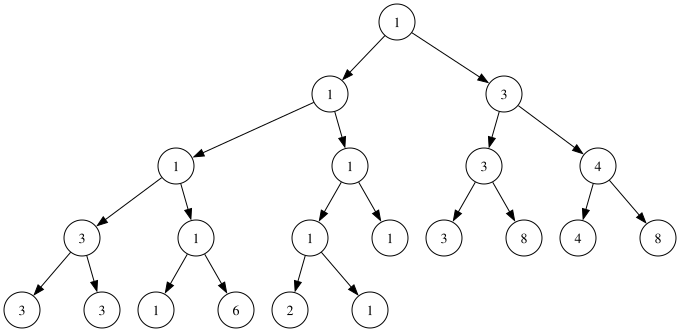

In [20]:
from visualizer import visualize_binary_tree
visualize_binary_tree(array_to_binary_tree([1,1,3,1,1,3,4,3,1,1,1,3,8,4,8,3,3,1,6,2,1]))

😃 Result: Accepted  
💯 Passed Test Case: 39 / 39  
🚀 Runtime: 0 ms, Memory: 19.4 MB  
🉑 Runtime Percentile: better than 100.00%, Memory Percentile: better than 8.03%  
📆 Finished At: Sun, 20 Sep 2026 22:10:18 GMT